In [ ]:
"""
LDA 

assumptions - 
Gaussian distribution of features within each class
Equal covariance matrices across classes
Independent observations
Different class means

"""

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
n = 200  # samples per class

# Shared covariance. LDA assumption
"""
         BP    Chol   BMI   Age
    BP  [10,    3,     1,    2  ]
    Ch  [ 3,   15,     2,    3  ]
    BMI [ 1,    2,     4,    1  ]
    Age [ 2,    3,     1,   20  ]
"""

cov = [[10, 3,  1,  2],
       [3,  15, 2,  3],
       [1,  2,  4,  1],
       [2,  3,  1,  20]]

# means of each predictors' classes
mean_low    = [110, 170, 22, 35]
mean_medium = [130, 200, 27, 50]
mean_high   = [155, 235, 32, 62]

X_low = np.random.multivariate_normal(mean_low, cov, n)
X_medium = np.random.multivariate_normal(mean_medium, cov, n)
X_high = np.random.multivariate_normal(mean_high, cov, n)

# vertical stack
X_clean = np.vstack([X_low, X_medium, X_high])
y = np.array([0] * n + [1] * n + [2] * n)

# add Gaussian noise to features
# Noise std is scaled per feature to create ~15-20% class overlap
noise_std = [8, 18, 3.5, 12]   # one value per feature
noise = np.random.normal(0, noise_std, X_clean.shape)
X_final = X_clean + noise

feature_names = ['blood_pressure', 'cholesterol', 'bmi', 'age']

df = pd.DataFrame(X_final, columns=feature_names)
df['risk_level'] = y
df['risk_label'] = df['risk_level'].map({0: 'Low', 1: 'Medium', 2: 'High'})

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (600, 6)
   blood_pressure  cholesterol        bmi        age  risk_level risk_label
0      104.965904   170.482809  22.631266  29.884706           0        Low
1      127.507391   191.887253  18.949766  46.080506           0        Low
2      116.524226   152.641779  24.482926  54.289890           0        Low
3       93.973133   149.544524  23.417227  41.554436           0        Low
4      113.792882   180.773426  21.375034  22.656082           0        Low


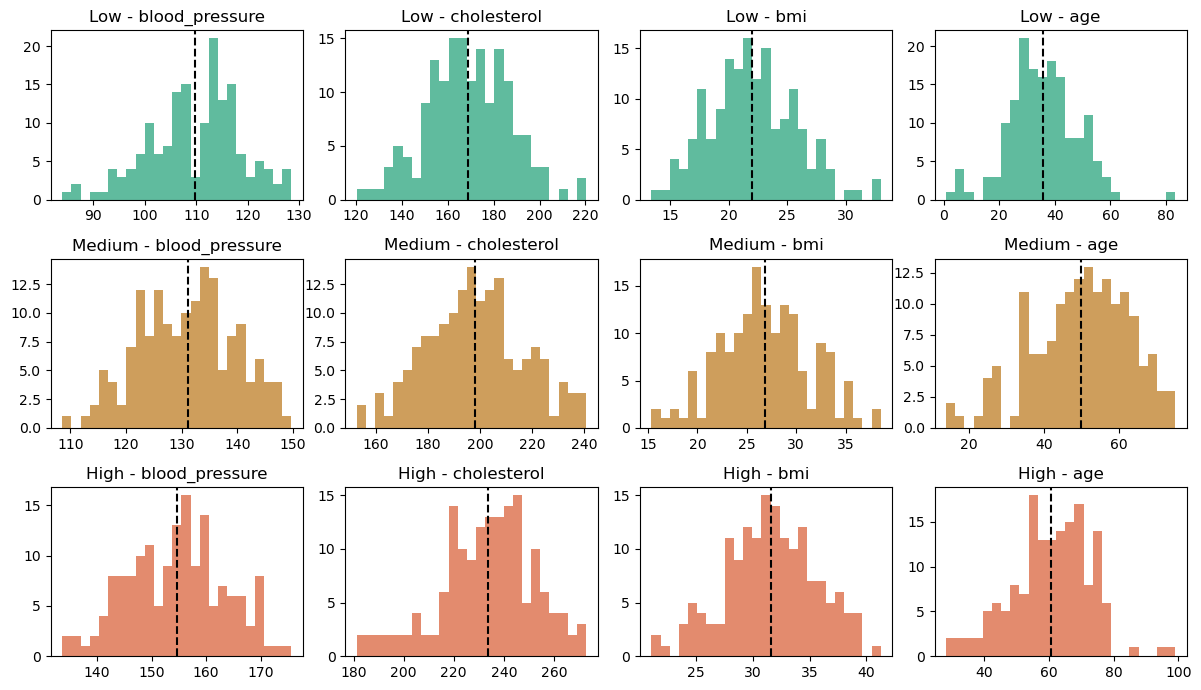

In [60]:
import matplotlib.pyplot as plt

class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
colors       = ['#1D9E75', '#BA7517', '#D85A30']

# Normality — a normal distribution looks like a bell curve
fig, axes = plt.subplots(3, 4, figsize=(12,7))

for cls in [0,1,2]:
    for j, feat in enumerate(inf_feats):
        ax = axes[cls, j]
        data = X_train[y_train == cls, j]
        ax.hist(data, bins=25, color=colors[cls], alpha=0.7)
        ax.axvline(data.mean(), linestyle='--', color='black')
        ax.set_title(f"{class_labels[cls]} - {feat}")
plt.tight_layout()
plt.show()

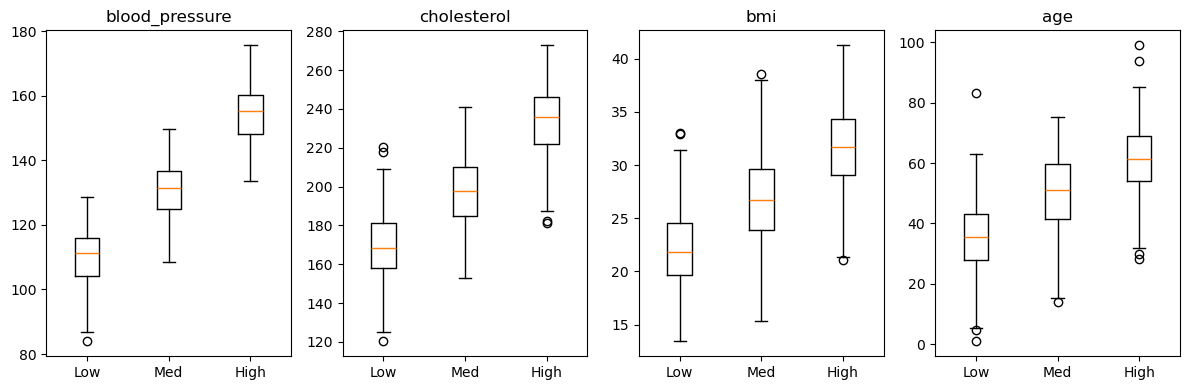

In [61]:
# equal spread — std per class per feature
# LDA needs similar spread across classes
fig, axes = plt.subplots(1,4, figsize=(12,4))
for j, feat in enumerate(inf_feats):
    data = [
        X_train[y_train == 0, j],
        X_train[y_train == 1, j],
        X_train[y_train == 2, j]
    ]

    axes[j].boxplot(data)
    axes[j].set_title(feat)
    axes[j].set_xticklabels(['Low','Med','High'])
plt.tight_layout()
plt.show()

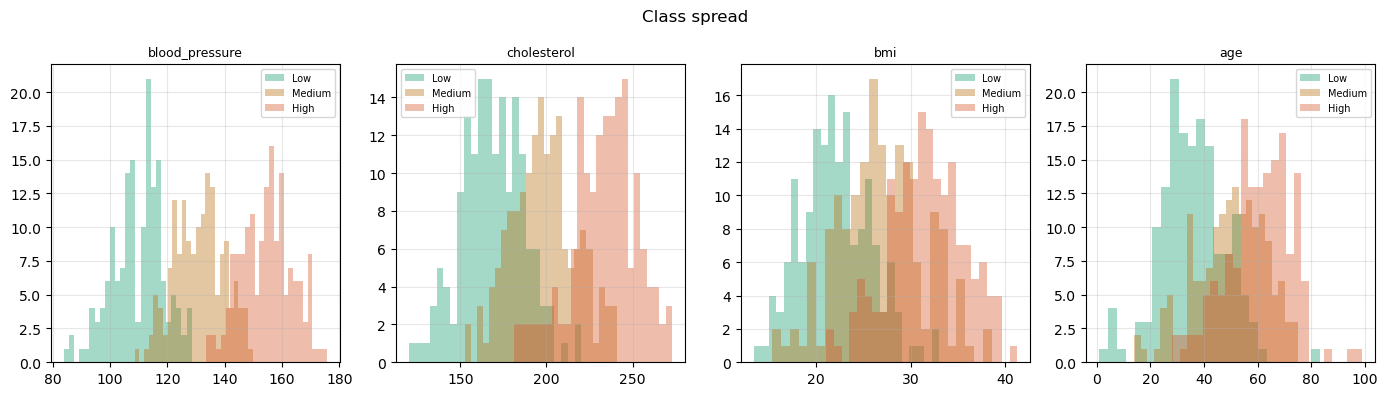

In [85]:
# class separation
# LDA only works if classes have different means
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Class spread", fontsize=12)

for j, feat in enumerate(inf_feats):
    for cls in [0,1,2]:
        data = X_train[y_train == cls, j]
        axes[j].hist(data,
                     bins=25,
                     alpha=0.4,
                     color=colors[cls],
                     label=class_labels[cls])

    axes[j].set_title(feat, fontsize=9)
    axes[j].legend(fontsize=7)
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
# stratify tells to maintain same ratio of classes in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lda = LinearDiscriminantAnalysis(store_covariance=True)
lda.fit(X_train_sc, y_train)

y_pred = lda.predict(X_test_sc)
y_prob = lda.predict_proba(X_test_sc)

print(f"LDA Accuracy: {accuracy_score(y_test, y_pred):.4f}")

LDA Accuracy: 0.9333


In [65]:
coef_df = pd.DataFrame(
    lda.scalings_,
    index=feature_names,
    columns=[f'LD{i+1}' for i in range(lda.scalings_.shape[1])]
).round(4)

print("Linear discriminant coefficients:")
print(coef_df)
print(f"\nExplained variance ratio: {lda.explained_variance_ratio_.round(4)}")

# estimated covariance matrix and means
print('\nCovariance matrix\n',lda.covariance_)

# each predictor and its mean of each class
print('\nClass means\n',lda.means_)

Linear discriminant coefficients:
                   LD1     LD2
blood_pressure -1.7509  0.3159
cholesterol    -0.9008  0.7393
bmi            -0.4989 -0.2723
age            -0.3483 -1.1121

Explained variance ratio: [0.9988 0.0012]

Covariance matrix
 [[ 0.18437634 -0.00520121 -0.01207234 -0.00252229]
 [-0.00520121  0.32912425 -0.0115163   0.00157852]
 [-0.01207234 -0.0115163   0.52224471  0.0261005 ]
 [-0.00252229  0.00157852  0.0261005   0.59628005]]

Class means
 [[-1.08642283 -0.97070508 -0.84851171 -0.81354273]
 [-0.03833786 -0.06201605  0.00395376  0.0763306 ]
 [ 1.12476069  1.03272112  0.84455794  0.73721213]]


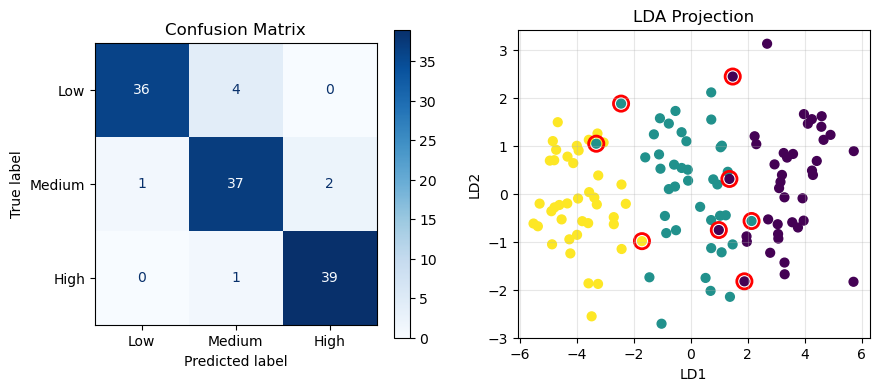

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Low','Medium','High'],
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix")

# ── LD1–LD2 plot ──
wrong = y_pred != y_test

axes[1].scatter(X_lda[:,0], X_lda[:,1], c=y_test, cmap="viridis", s=40)

axes[1].scatter(
    X_lda[wrong,0],
    X_lda[wrong,1],
    facecolors="none",
    edgecolors="red",
    s=120,
    linewidths=2
)

axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].set_title("LDA Projection")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
"""
QDA

assumptions - 
Gaussian distribution of features within each class
Different covariance matrices across classes
Independent observations
Different class means

"""

In [127]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

np.random.seed(42)
n = 200

# class means
mean_low    = [118, 185, 24, 42]
mean_medium = [128, 198, 27, 50]
mean_high   = [138, 211, 30, 58]

# each class now has its own covariance matrix
# Low risk: tight cluster, low variance, weak correlations
# (healthy patients tend to cluster tightly)
cov_low = [[6,  1,   0.5, 1 ],
           [1,  8,   1,   1 ],
           [0.5,1,   2,   0.5],
           [1,  1,   0.5, 10]]

# Medium risk: moderate spread, moderate correlations
# (mixed patients, more variability)
cov_medium = [[15,  6,   2,  4 ],
              [6,   25,  3,  5 ],
              [2,   3,   6,  2 ],
              [4,   5,   2,  30]]

# High risk: wide spread, strong correlations between features
# (sick patients show compounding risk factors together)
cov_high = [[25,  12,  4,  8 ],
            [12,  40,  6,  10],
            [4,   6,   10, 4 ],
            [8,   10,  4,  50]]

X_low = np.random.multivariate_normal(mean_low, cov_low, n)
X_medium = np.random.multivariate_normal(mean_medium, cov_medium, n)
X_high = np.random.multivariate_normal(mean_high, cov_high, n)

X_clean = np.vstack([X_low, X_medium, X_high])
y = np.array([0]*n + [1]*n + [2]*n)

# moderate Gaussian noise
noise_std = [4, 8, 1.5, 6]
noise     = np.random.normal(0, noise_std, X_clean.shape)
X_final   = X_clean + noise

feature_names = ['blood_pressure', 'cholesterol', 'bmi', 'age']

df = pd.DataFrame(X_final, columns=feature_names)
df['risk_level'] = y
df['risk_label']  = df['risk_level'].map({0: 'Low', 1: 'Medium', 2: 'High'})

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (600, 6)
   blood_pressure  cholesterol        bmi        age  risk_level risk_label
0      115.847061   184.602630  24.997904  38.887118           0        Low
1      128.150566   194.149307  23.149501  47.422287           0        Low
2      121.026892   178.180972  24.942273  51.960573           0        Low
3      108.413743   174.322246  23.979444  46.207651           0        Low
4      119.461685   190.854526  23.150883  36.810296           0        Low


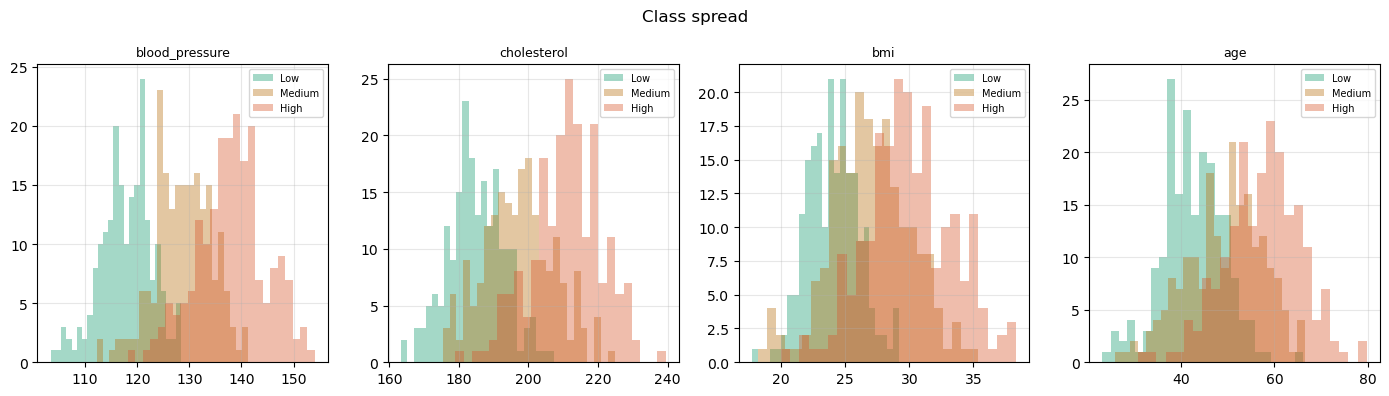

In [128]:
colors      = ['#1D9E75', '#BA7517', '#D85A30']
class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Class spread", fontsize=12)

for j, feat in enumerate(feature_names):
    for cls in [0, 1, 2]:
        data = X_final[y == cls, j]
        axes[j].hist(data, 
                     bins=25, 
                     alpha=0.4,
                     color=colors[cls],
                     label=class_labels[cls])
    axes[j].set_title(feat, fontsize=9)
    axes[j].legend(fontsize=7)
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [129]:
# the class spread - Low is tight, High is wide

In [130]:
# std per class should be different
# Low should be smallest, High largest
print("Std per class per feature")
print("-" * 60)
print(f"  {'feature':20s} | {'Low':>8} | {'Medium':>8} | {'High':>8}")
print("-" * 60)
for j, feat in enumerate(feature_names):
    stds = [X_final[y == cls, j].std() for cls in [0, 1, 2]]
    print(f"  {feat:20s} | {stds[0]:8.2f} | {stds[1]:8.2f} | {stds[2]:8.2f}")

Std per class per feature
------------------------------------------------------------
  feature              |      Low |   Medium |     High
------------------------------------------------------------
  blood_pressure       |     4.92 |     5.46 |     6.54
  cholesterol          |     8.09 |    10.06 |    10.03
  bmi                  |     1.98 |     3.14 |     3.36
  age                  |     6.62 |     8.24 |     8.15


In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train shape:", X_train_sc.shape)
print("Test shape :", X_test_sc.shape)

qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_train_sc, y_train)

y_pred = qda.predict(X_test_sc)
y_prob = qda.predict_proba(X_test_sc)

print(f"\nQDA Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Train shape: (480, 4)
Test shape : (120, 4)

QDA Accuracy: 0.8083


In [132]:
# per-class covariance matrices
for i, cls in enumerate([0, 1, 2]):
    print(f"Covariance matrix — {class_labels[cls]} risk:")
    cov_df = pd.DataFrame(
        qda.covariance_[i],
        index=feature_names,
        columns=feature_names
    ).round(3)
    print(cov_df)
    print()

Covariance matrix — Low risk:
                blood_pressure  cholesterol    bmi    age
blood_pressure           0.247        0.023 -0.002 -0.004
cholesterol              0.023        0.327 -0.048  0.059
bmi                     -0.002       -0.048  0.260  0.026
age                     -0.004        0.059  0.026  0.433

Covariance matrix — Medium risk:
                blood_pressure  cholesterol    bmi    age
blood_pressure           0.305        0.026 -0.026  0.054
cholesterol              0.026        0.467  0.057 -0.040
bmi                     -0.026        0.057  0.717 -0.016
age                      0.054       -0.040 -0.016  0.720

Covariance matrix — High risk:
                blood_pressure  cholesterol    bmi    age
blood_pressure           0.452       -0.003  0.088  0.078
cholesterol             -0.003        0.482  0.083  0.034
bmi                      0.088        0.083  0.829  0.211
age                      0.078        0.034  0.211  0.714



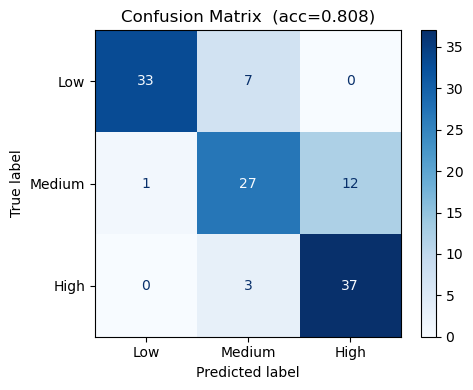

In [133]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Low', 'Medium', 'High'],
    cmap='Blues', ax=ax
)
ax.set_title(f"Confusion Matrix  (acc={accuracy_score(y_test, y_pred):.3f})")

plt.tight_layout()
plt.show()

In [ ]:
"""
Naive Bayes

assumptions -
Features are conditionally independent given the class
Class prior probabilities exist
Feature likelihoods can be estimated for each class (e.g., Gaussian, multinomial, Bernoulli depending on variant)
Observations are independent

"""